# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos.
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas.
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [ ]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son categóricas?**



# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


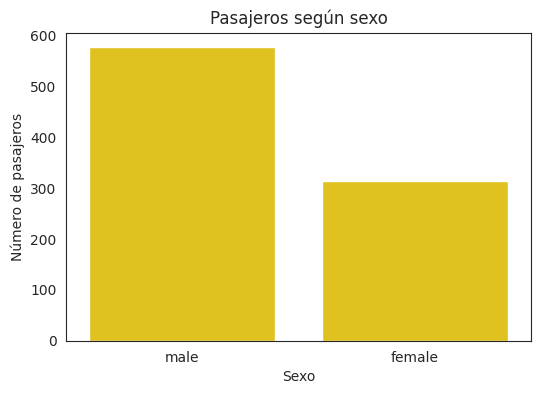

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?


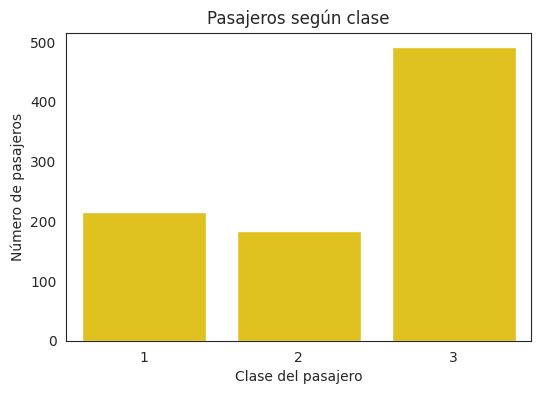

In [ ]:
# Escriba aquí su código


plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Pclass", color="gold")

plt.xlabel("Clase del pasajero")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase")

#La clase con mas pasajeros es la tres de fuera. Podemos ver que la 2 y 1 estan casi las mismas.

plt.show()

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
- ¿La distribución parece simétrica?
- ¿El número de bins cambia su interpretación?


Text(0.5, 1.0, 'Pasajeros según edqd')

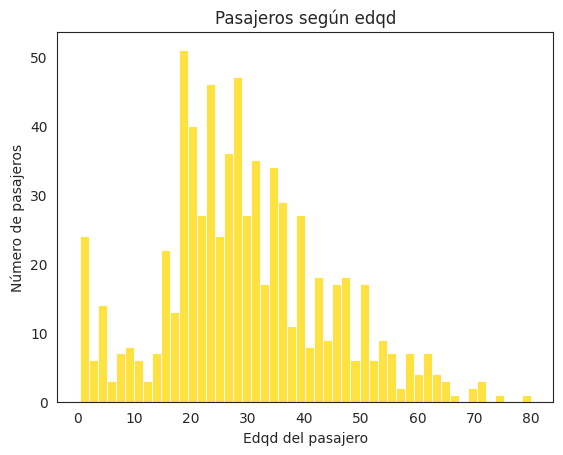

In [ ]:
# Escriba aquí su código


sns.histplot(data=titanic, x="Age", color="gold", bins=50)

plt.xlabel("Edad del pasajero")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según edad")

#Los pasajeros tienen sobre 20/25 años.La distribucion es casi simetrica pero hay un gran noñbre de niños aue tengan menos de 5 años.
# El numero de bins no cambia toda la interpretation pero nos permite entender mejor la distribucion.


**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?


Text(0.5, 1.0, 'Pasajeros según tarifa')

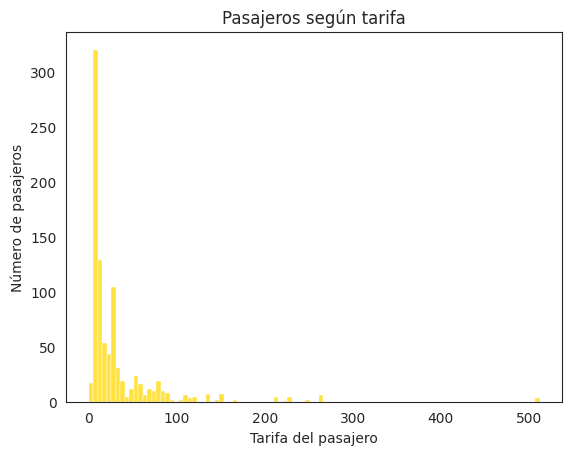

In [ ]:
sns.histplot(data=titanic, x="Fare", color="gold", bins=100)

plt.xlabel("Tarifa del pasajero")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según tarifa")

# No, la distribucion no esta simétrica, la mayor parte de las personas pagaron sobre 10. Si hay personas que pagaban mas de 500.
# Hay un gran diferencia social entre las pasajeros aunque la mayor parte estan de la misma clase social.


# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [ ]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


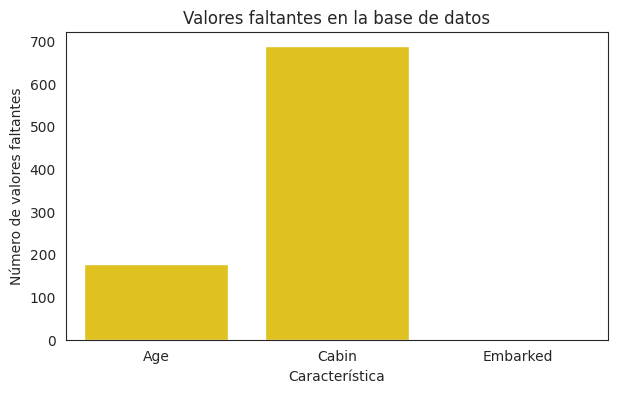

In [ ]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?


In [ ]:
# Escriba aquí su código

media = titanic["Age"].mean()
mediana = titanic["Age"].median()
print(f"La media de edad es {media} y la mediana es {mediana}")

#Son siñilares, depende de la desviación típica y de la reparticion. En nuestro caso la distribucion esta casi simetrica, asi es una buena representacion aunque no nos perñite entender la gran parte de jovenes en la embarcacion.


La media de edad es 29.69911764705882 y la mediana es 28.0


**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?

No me parece tanto mal pero como tenemos muchas datos es mas resonable de simple occultar esta lineas.

- Qué problema podría producir esa decisión en la distribución de edades?

El problema es que vamos a perder interpretation y la analysis despues quizas sera falsa.

- Qué otra estrategia consideraría?

Occultar las lineas pero pienso que la estrategia de la media es bien.


**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?

Si tenemos otro dataset que le permite puede ser una buena idea pero en nuestro caso pienso que no.

- Eliminaría la característica?

Parece una caracteristica interssante pero con tantos datos faltantes pienso aue seria mejor de elimimarla.

- Podría el hecho de conocer o no la cabina contener información por sí mismo?

Esta caracteristica está correlacionada con la clase del pasajeros, así no es necessito de mantenerla.

No hay una única respuesta correcta: justifique su decisión.


**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?

Para mi, creo que el caso se parece a el de la edad pero con menos datos faltantes, pienso que seria mas simple de eliminar las lineas co datos faltantes.

- Por qué el tratamiento puede ser distinto al de `Cabin`?

Poraue aqui hay mucho menos datos faltantes.


# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


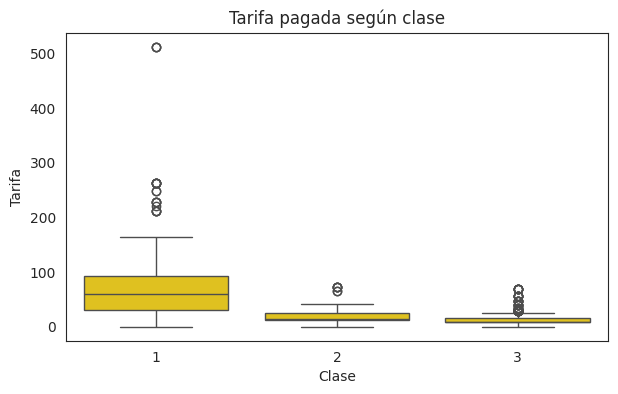

In [ ]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?

Si por supuesto pero no es el unico factor.

- Hay dispersión dentro de cada clase?

En las clases 2 y 3 los precios parecen ser casi los mismos para toda la clase pero podemos ver que la clase 1 muestra una desviación típica mucho mayor.

- Existen valores extremos?

En cada clase podemos ver valores atípicos, la dispersion la mas importante está en la clase 1 con entre los que destaca un caso de más de 500 dólares.

- Diría que `Fare` y `Pclass` contienen exactamente la misma información?

No, pienso aue es una simplification que no esta necessaria. Ahora, si decidimos de eliminar una de estas caracteristica pienso que la analysis despues siempre sera possible.


### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?

Los major de edad estan casi todos en clase 1 donde hay de todas edad. Aparte de eso las edad parecen ser los ñisños en clase 3 y 2. En la clase 3 estan un poco mas joven.

- Qué diferencias observa?

"


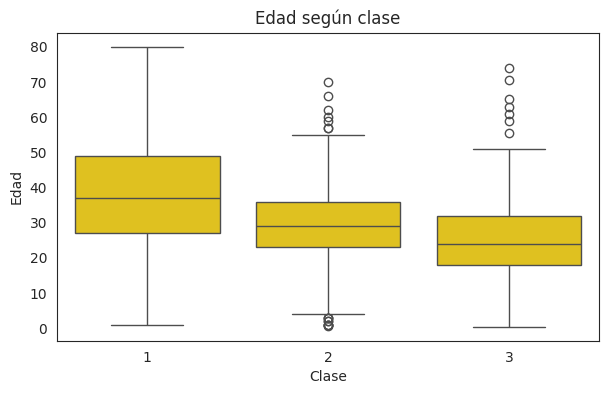

In [ ]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Age", color='gold')

plt.xlabel("Clase")
plt.ylabel("Edad")
plt.title("Edad según clase")

plt.show()


**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [ ]:
# Complete el código

titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] + 1


**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?

Sola

- Hay grupos familiares muy grandes?

Hay un grupo en particular de mas de 10 personas.

- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?

Si, es diferente pero Familia me parece mas interessante


Text(0.5, 1.0, 'Pasajeros según grupo familiar')

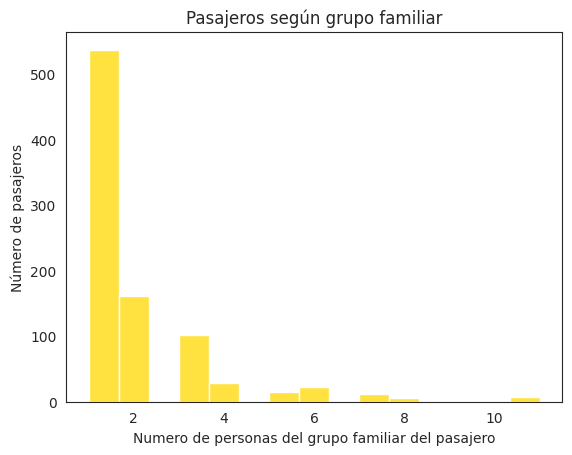

In [ ]:
# Escriba aquí su código

sns.histplot(data=titanic, x="Familia", color="gold", bins=15)

plt.xlabel("Numero de personas del grupo familiar del pasajero")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según grupo familiar")

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


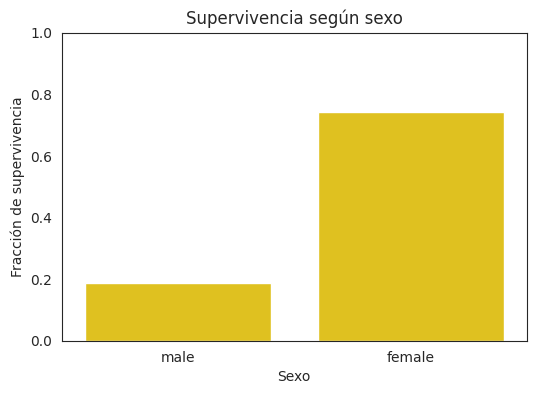

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?

No, hay mas mujeres.

- Podemos concluir a partir de este gráfico por qué existe la diferencia?

Si, las mujeres en primera es una regla muy conocida, me parece normal que estan las que surviven.


### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?

Si

- Existe una tendencia?

Si, hay mas supervivencia en la clase 1 aue las otras, y hay mas en la clase " que en la tres. Quizas la clase una esta en una mejor posicion, quizas los personnas con mas dineros tiene mejoras opciones para sobrevivir.


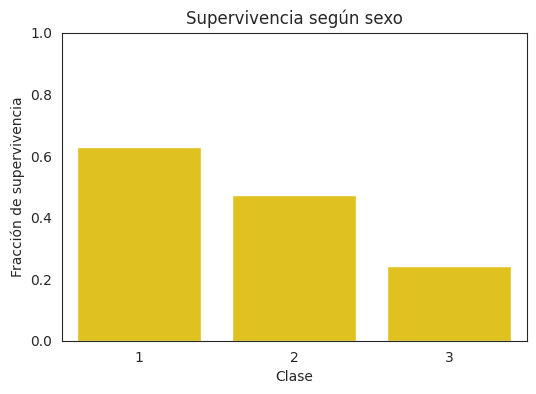

In [ ]:
# Escriba aquí su código


plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color='gold')

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase")
plt.ylim(0,1)

plt.show()

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?

Los dos extremos son los aue sobreviven el mas, lo  que es normal, niños y mayor de edad primero.

- Hay algún grupo de edad que llame particularmente su atención?

En el centro es el minimo de supervivencia, podemos imaginar que qyudqn las otras mas.


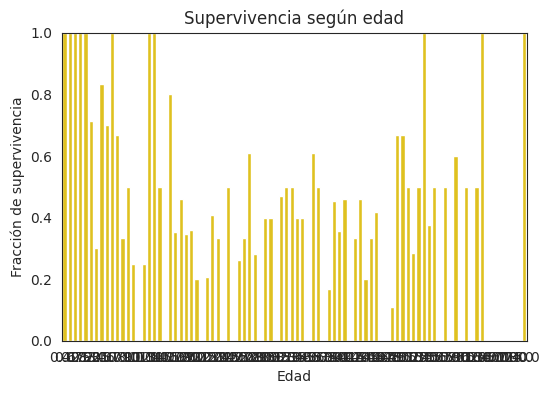

In [ ]:
# Escriba aquí su código


plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Age", y="Survived", errorbar=None, color='gold')

plt.xlabel("Edad")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según edad")
plt.ylim(0,1)

plt.show()


**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?

No encuentro una repuesta evidente, podemos piensar que los grupos de 4 son los mejor pero con tanpoco valor puede ser una coincidiencia.

- La relación parece simple?

No, es complicado.

- Qué ocurre con los grupos familiares grandes?

La superviviencia no es buena, quizas estan demasiado y mueron intentando ayudar otras.


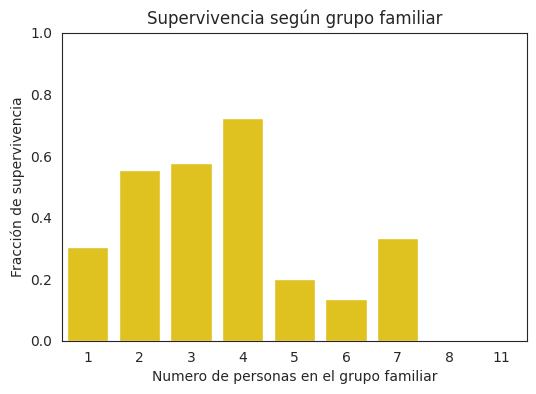

In [ ]:
# Escriba aquí su código

plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color='gold')

plt.xlabel("Numero de personas en el grupo familiar")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según grupo familiar")
plt.ylim(0,1)

plt.show()


# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


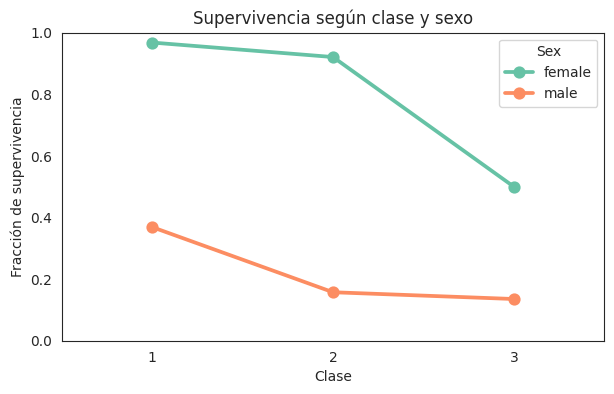

In [ ]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?

Casi, la differencia es que hay muchos muertos en la clase uno lo que significa muchas menos superviviencia de los mujeres entre la clase 2 y 3 aunque los hombres aue mueren mucho tambien en la clase dos sobreviven el mismo

- Qué información se perdía cuando mirábamos solamente `Pclass`?

Que las personnas que mueren mas que antes entre clase 2 y 3 son las mujeres

- Qué información se perdía cuando mirábamos solamente `Sex`?

Que las mujeres de la clase 1 todqs sobreviven.

- Hay algún grupo particularmente favorecido o desfavorecido?

Las mujeres de la clase 3 tienen una superviviencia demasiado peor que las otras.



### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [ ]:
# Complete el código
condiciones = [
    titanic["Age"] < 16,
    titanic["Sex"] == "female",
    titanic["Sex"] == "male"
]
opciones = ["niño/a", "mujer", "hombre"]

titanic["Persona"] = np.select(condiciones, opciones, default="desconocido")


# Revise el resultado
titanic["Persona"].value_counts()


,count
Persona,
hombre,537
mujer,271
niño/a,83


**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?

Los resultados son similares en el caso de los niños, pero se observa, no obstante, que los niños de la clase 1 tienen menos posibilidades de sobrevivir que los de la clase 2, como si la clase 2 hubiera intentado a toda costa que los niños sobrevivieran. La mejor combinacion son los ninos de la clase 2.


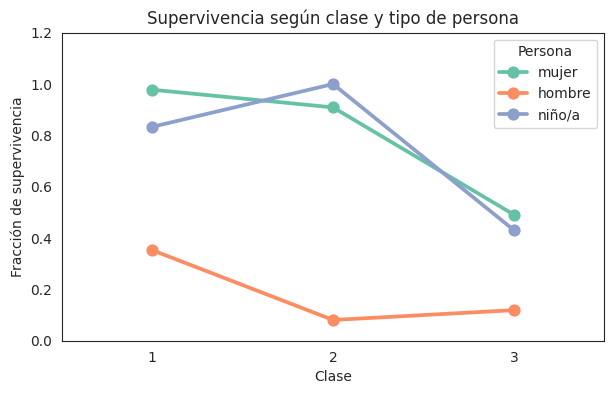

In [ ]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Persona",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y tipo de persona")
plt.ylim(0,1.2)

plt.show()


**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


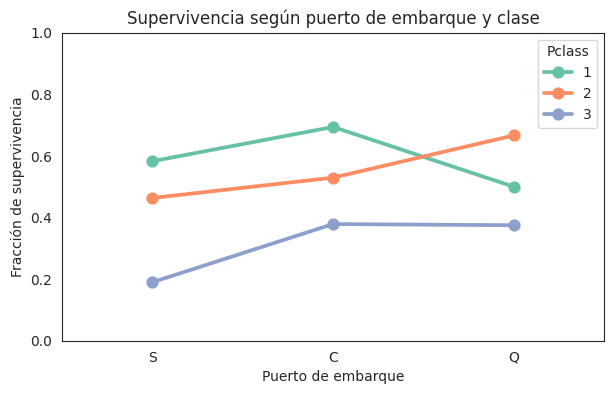

In [ ]:
# Pregunta:

#El grafico muestra que los pasajeros de primera clase tienen una mayor fraccion de supervivencia en casi todos los puertos, especialmente en Cherbourg. En cambio, los pasajeros de tercera clase tienen siempre la menor probabilidad de sobrevivir, sobre todo los que embarcaron en Southampton.

# Código:

plt.figure(figsize=(7, 4))

sns.pointplot(data=titanic,
              x="Embarked",
              y="Survived",
              hue="Pclass",
              palette="Set2",
              errorbar=None)

plt.xlabel("Puerto de embarque")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según puerto de embarque y clase")
plt.ylim(0, 1)

plt.show()


# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**

No podemos concluir con seguridad que se dio prioridad a mujeres y niños unicamente a partir de estos datos, ya que solo observamos el resultado final y no las reglas de evacuacion.

- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**

Necesitaríamos testimonios de la tripulacion, registros de las ordenes dadas en cubierta o datos sobre el orden de acceso a los botes salvavidas.

- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

Otras explicaciones podrian ser que las mujeres y los ninos tenian camarotes ubicados mas cerca de la cubierta o que habia mas hombres viajando en tercera clase, donde la mortalidad fue mucho mayor.

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo : Hombres
- clase : 3
- edad : ~28
- tamaño de familia : ~solo en general y familia desde 2 à mas de 10


### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo : Mujeres
- clase : 1
- edad : Jovenes y mayor de edad
- viajar solo o acompañado : Accompanado de un poco



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

La mayor diferencia en cuanto a la mortalidad entre la clase 2 y la 1 se da en el caso de los niños.


### 4. Encontró características que contienen información relacionada?

La cabin y la clase. Tambien la clase y el precio.


### 5. Qué resultado le pareció más inesperado?

El resultado mas inesperado fue ver que los pasajeros de primera clase que embarcaron en Queenstown tienen una menor fraccion de supervivencia que los de segunda clase en ese mismo puerto.

Observacion: los datos muestran que en el puerto Q la linea de la primera clase cae por debajo de la segunda clase.

Hipotesis: esto pudo ocurrir porque habia muy pocos pasajeros de primera clase en ese puerto y las caracteristicas de ese pequeno grupo particular distorsionaron la tendencia general.


# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo : Mujer
- edad : Menos de 16 anos
- clase : 2
- tamaño del grupo familiar : 4
- otras características que hayan resultado relevantes : De Queenstown

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*

El pasajero tipico que sobrevivio era una mujer o un nino menor de 16 anos, perteneciente a la segunda clase, que viajaba en un grupo familiar de cuatro personas y embarco en el puerto de Queenstown.
